<a href="https://colab.research.google.com/github/sdgunawijaya/CNNmodel/blob/main/CNN%20Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os
from PIL import Image
import numpy as np

# --- Configuration ---
# Define target dimensions for resizing. You can change this to (128, 128) if needed.
target_size = (64, 64)

# Define input base directory and subdirectories containing images
input_base_dir = '/content/'
# These subdirectories are assumed based on the previous 'Dataset.zip' unzipping
subdirectories = ['Eye', 'Left_hand', 'Right_hand']

# Number of images to process for demonstration. Set to None to process all.
max_images_to_process = None
# -------------------

processed_images = []
processed_count = 0

print(f"Starting image processing: resizing to {target_size} and normalizing pixels to [0, 1]...")

for sub_dir_name in subdirectories:
    input_dir = os.path.join(input_base_dir, sub_dir_name)
    if not os.path.exists(input_dir):
        print(f"Warning: Directory '{input_dir}' not found, skipping.")
        continue

    print(f"\nSearching for images in: '{input_dir}'")
    for root, _, files in os.walk(input_dir):
        for file in files:
            if max_images_to_process is not None and processed_count >= max_images_to_process:
                break # Stop if demonstration limit is reached

            # Check for common image file extensions
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                img_path = os.path.join(root, file)
                try:
                    # 1. Open the image
                    with Image.open(img_path) as img:
                        # 2. Resize image
                        img_resized = img.resize(target_size)

                        # 3. Convert to NumPy array
                        # Ensure image is in a format suitable for NumPy (e.g., RGB)
                        if img_resized.mode != 'RGB':
                            img_resized = img_resized.convert('RGB')
                        img_array = np.array(img_resized)

                        # 4. Normalize pixels to [0, 1]
                        # Convert data type to float and divide by 255.0 (max pixel value for 8-bit images)
                        img_normalized = img_array.astype(np.float32) / 255.0

                        processed_images.append(img_normalized)
                        processed_count += 1

                        print(f"  Processed '{file}': Original size {img.size}, Resized {img_resized.size}, Normalized shape {img_normalized.shape}, Min pixel {np.min(img_normalized):.2f}, Max pixel {np.max(img_normalized):.2f}")

                except Exception as e:
                    print(f"Error processing '{img_path}': {e}")

            if max_images_to_process is not None and processed_count >= max_images_to_process:
                break
        if max_images_to_process is not None and processed_count >= max_images_to_process:
            break

print(f"\nDemonstration complete. Successfully processed {processed_count} images.")
if processed_images:
    print(f"The first processed image array's shape: {processed_images[0].shape}")
    print(f"The first processed image array's data type: {processed_images[0].dtype}")
else:
    print("No images were processed.")

print("\nWhat would you like to do next?")
print("1. Change `target_size` to `(128, 128)`?")
print("2. Process all images by setting `max_images_to_process = None`?")
print("3. Save the processed images to a new output directory?")
print("4. Load these processed images into a suitable format for a machine learning dataset?")


Starting image processing: resizing to (64, 64) and normalizing pixels to [0, 1]...

Searching for images in: '/content/Eye'
  Processed 'download (1).jpg': Original size (225, 225), Resized (64, 64), Normalized shape (64, 64, 3), Min pixel 0.00, Max pixel 1.00
  Processed 'download (4).jpg': Original size (259, 194), Resized (64, 64), Normalized shape (64, 64, 3), Min pixel 0.00, Max pixel 1.00
  Processed 'images (5).jpg': Original size (293, 172), Resized (64, 64), Normalized shape (64, 64, 3), Min pixel 0.01, Max pixel 1.00
  Processed 'images (7).jpg': Original size (260, 194), Resized (64, 64), Normalized shape (64, 64, 3), Min pixel 0.00, Max pixel 1.00
  Processed 'download (2).jpg': Original size (344, 147), Resized (64, 64), Normalized shape (64, 64, 3), Min pixel 0.08, Max pixel 1.00
  Processed 'images (3).jpg': Original size (300, 168), Resized (64, 64), Normalized shape (64, 64, 3), Min pixel 0.01, Max pixel 0.98
  Processed 'download (5).jpg': Original size (260, 194), R

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [14]:
X = np.array(processed_images)

# Create numerical labels based on the specified counts
# 20 images for 'Eye' (label 0)
# 15 images for 'Left_hand' (label 1)
# 15 images for 'Right_hand' (label 2)
# Total = 50 images

y_list = ([0] * 20) + ([1] * 15) + ([2] * 15)
y = np.array(y_list)

print(f"Shape of X (features): {X.shape}")
print(f"Data type of X: {X.dtype}")
print(f"Shape of y (labels): {y.shape}")
print(f"Data type of y: {y.dtype}")
print(f"First 5 labels: {y[:5]}")
print(f"Last 5 labels: {y[-5:]}")

Shape of X (features): (50, 64, 64, 3)
Data type of X: float32
Shape of y (labels): (50,)
Data type of y: int64
First 5 labels: [0 0 0 0 0]
Last 5 labels: [2 2 2 2 2]


In [15]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets (80/20 split, stratified)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")

# Check the distribution of labels in training and validation sets
print("\nTraining label distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  Label {label}: {count} samples")

print("\nValidation label distribution:")
unique_val, counts_val = np.unique(y_val, return_counts=True)
for label, count in zip(unique_val, counts_val):
    print(f"  Label {label}: {count} samples")

Shape of X_train: (40, 64, 64, 3)
Shape of y_train: (40,)
Shape of X_val: (10, 64, 64, 3)
Shape of y_val: (10,)

Training label distribution:
  Label 0: 16 samples
  Label 1: 12 samples
  Label 2: 12 samples

Validation label distribution:
  Label 0: 4 samples
  Label 1: 3 samples
  Label 2: 3 samples


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the CNN model
model = Sequential([
    # First convolutional layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    # Second convolutional layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # Flatten the output for the dense layers
    Flatten(),
    # Dense hidden layer
    Dense(128, activation='relu'),
    # Output layer (3 classes: Eye, Left_hand, Right_hand)
    Dense(3, activation='softmax')
])

# Display the model summary to verify the architecture
model.summary()

print("CNN model defined successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,539 (6.20 MB)

 Trainable params: 1,625,539 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

CNN model defined successfully.


In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("CNN model compiled successfully with Adam optimizer and sparse_categorical_crossentropy loss.")

CNN model compiled successfully with Adam optimizer and sparse_categorical_crossentropy loss.


In [18]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
print("CNN model training complete.")

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.2875 - loss: 1.4386 - val_accuracy: 0.3000 - val_loss: 1.2671
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.2875 - loss: 1.3888 - val_accuracy: 0.3000 - val_loss: 1.2467
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2938 - loss: 1.2624 - val_accuracy: 0.3000 - val_loss: 1.0555
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3542 - loss: 1.0523 - val_accuracy: 0.4000 - val_loss: 1.0642
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3917 - loss: 1.0591 - val_accuracy: 0.4000 - val_loss: 0.9708
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.3979 - loss: 0.9565 - val_accuracy: 0.5000 - val_loss: 0.9317
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5583 - loss: 0.8765 - val_accuracy: 0.5000 - val_loss: 0.8844
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.7562 - loss: 0.7908 - val_accuracy: 0.7000 - val_loss:

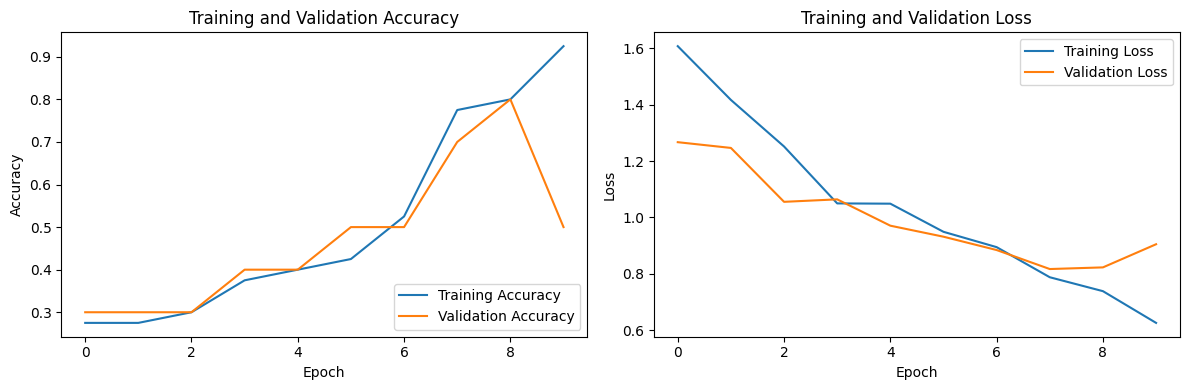

Accuracy and loss graphs plotted successfully.


In [19]:
import matplotlib.pyplot as plt

# Get the history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

# Plot training and validation accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()
print("Accuracy and loss graphs plotted successfully.")

# Task
Upload a new image file, then preprocess it by resizing to (64, 64) and normalizing pixel values to [0, 1]. After preprocessing, use the trained CNN model to classify the image, and finally display the predicted class label along with the confidence scores.

In [20]:
from google.colab import files

print("Please upload your image file:")
uploaded = files.upload()

# Assuming only one file is uploaded for this example
if uploaded:
    filename = list(uploaded.keys())[0]
    print(f'User uploaded file "{filename}"')

    try:
        # Load the uploaded image
        uploaded_image = Image.open(filename)

        # Display the image to confirm
        print("Displaying uploaded image:")
        uploaded_image.show()

    except Exception as e:
        print(f"Error loading or displaying image: {e}")
else:
    print("No file was uploaded.")

Please upload your image file:


Saving images (7).jpg to images (7).jpg
User uploaded file "images (7).jpg"
Displaying uploaded image:


In [21]:
import numpy as np

# Define target dimensions for resizing, consistent with training data
target_size = (64, 64)

# Preprocess the uploaded image
# 1. Resize image
preprocessed_image = uploaded_image.resize(target_size)

# 2. Convert to NumPy array
# Ensure image is in a format suitable for NumPy (e.g., RGB)
if preprocessed_image.mode != 'RGB':
    preprocessed_image = preprocessed_image.convert('RGB')
img_array_single = np.array(preprocessed_image)

# 3. Normalize pixels to [0, 1]
# Convert data type to float and divide by 255.0
img_normalized_single = img_array_single.astype(np.float32) / 255.0

# Add a batch dimension, as the model expects a batch of images
img_for_prediction = np.expand_dims(img_normalized_single, axis=0)

print(f"Original image size: {uploaded_image.size}")
print(f"Resized image size: {preprocessed_image.size}")
print(f"Normalized image shape for prediction: {img_for_prediction.shape}")
print(f"Min pixel value: {np.min(img_for_prediction):.2f}")
print(f"Max pixel value: {np.max(img_for_prediction):.2f}")

Original image size: (275, 183)
Resized image size: (64, 64)
Normalized image shape for prediction: (1, 64, 64, 3)
Min pixel value: 0.04
Max pixel value: 0.94


In [22]:
import numpy as np

# Make a prediction using the trained model
predictions = model.predict(img_for_prediction)

# Get the predicted class (the one with the highest probability)
predicted_class_index = np.argmax(predictions[0])

# Get the confidence score for the predicted class
confidence_score = predictions[0][predicted_class_index]

# Define class names based on the labels used during training
class_names = ['Eye', 'Left_hand', 'Right_hand']
predicted_class_name = class_names[predicted_class_index]

print(f"\nPrediction results:")
print(f"  Probabilities: {predictions[0]}")
print(f"  Predicted Class Index: {predicted_class_index}")
print(f"  Predicted Class Name: {predicted_class_name}")
print(f"  Confidence: {confidence_score:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

Prediction results:
  Probabilities: [0.3186422  0.21785161 0.46350622]
  Predicted Class Index: 2
  Predicted Class Name: Right_hand
  Confidence: 0.46
